# 02 — Feature pipeline: waveform → 8000 samples → mel → log(P+1e-6) → CMVN (64×32)
Dùng `src/audio.py` và `src/features.py`.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plotstyle; plotstyle.apply()
from plotstyle import SERIES, TEXT2
FIG = ROOT / 'results' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
import librosa
from audio import load_wav, fix_length, length_action
from features import MEL_CFG, mel_power, logmel_raw, cmvn, logmel
df = pd.read_csv(ROOT / 'data' / 'manifest.csv')
MEL_CFG

{'sr': 8000,
 'n_fft': 256,
 'win_length': 256,
 'hop_length': 256,
 'window': 'hann',
 'center': True,
 'pad_mode': 'constant',
 'n_mels': 64,
 'fmin': 50.0,
 'fmax': 4000.0,
 'power': 2.0,
 'htk': False,
 'norm': 'slaney'}

## 1–3. Load waveform, chuẩn hóa 8000 samples, vẽ waveform

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


7_jackson_32.wav sr 8000 raw 4301 -> 8000 float32 PAD


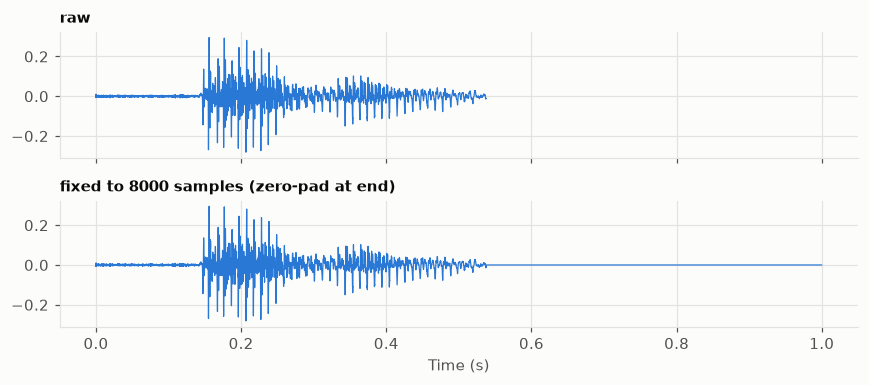

In [2]:
row = df[df.filename == '7_jackson_32.wav'].iloc[0]
y_raw, sr = load_wav(ROOT / row.path)
y = fix_length(y_raw)
print(row.filename, 'sr', sr, 'raw', len(y_raw), '->', len(y), y.dtype, length_action(len(y_raw)))
fig, axes = plt.subplots(2, 1, figsize=(8, 3.6), sharex=True)
axes[0].plot(np.arange(len(y_raw)) / sr, y_raw, color=SERIES[0], lw=0.8); axes[0].set_title('raw', loc='left', fontsize=10)
axes[1].plot(np.arange(len(y)) / sr, y, color=SERIES[0], lw=0.8); axes[1].set_title('fixed to 8000 samples (zero-pad at end)', loc='left', fontsize=10)
axes[1].set_xlabel('Time (s)'); fig.tight_layout(); plt.show()

## 4–7. Mel power, log-mel, shape

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


mel power shape (64, 32)  log-mel shape (64, 32)
P range [0.00e+00, 5.24e-01]  log(P+1e-6) range [-13.816, -0.647]  CMVN S mean -2.01e-07 std 1.000


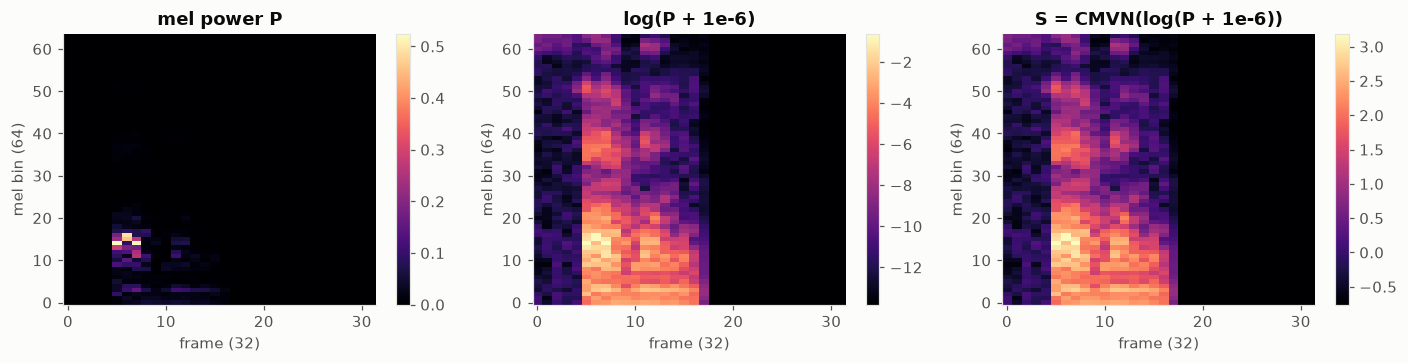

In [3]:
P = mel_power(y)
S_log = logmel_raw(y)
S = logmel(y)
print('mel power shape', P.shape, ' log-mel shape', S.shape)
assert S.shape == (64, 32)
print(f'P range [{P.min():.2e}, {P.max():.2e}]  log(P+1e-6) range [{S_log.min():.3f}, {S_log.max():.3f}]  CMVN S mean {S.mean():.2e} std {S.std():.3f}')
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, M, t in [(axes[0], P, 'mel power P'), (axes[1], S_log, 'log(P + 1e-6)'), (axes[2], S, 'S = CMVN(log(P + 1e-6))')]:
    im = ax.imshow(M, origin='lower', aspect='auto', cmap='magma'); ax.set_title(t); ax.grid(False)
    ax.set_xlabel('frame (32)'); ax.set_ylabel('mel bin (64)'); fig.colorbar(im, ax=ax)
fig.tight_layout(); plt.show()

### Vì sao không dùng `log1p(P)` như đặc tả ban đầu
Audio float32 nằm trong [-1, 1] nên `P` rất nhỏ; khi `P ≪ 1` thì `log(1+P) ≈ P` — đặc trưng thành power tuyến tính, phụ thuộc âm lượng từng speaker (classifier LOSO chỉ đạt 21.8%). Dự án dùng `S = CMVN(log(P + 1e-6))` (quyết định ngày 2026-10-05, xem `results/logs/diagnostics/feature_variant_diagnostic.md`). Cell dưới so sánh hai cách trên toàn dataset.

In [4]:
from dataset import load_logmel_cache
S_all, idx = load_logmel_cache()
P_all = {f: mel_power(fix_length(load_wav(ROOT / p)[0])) for f, p in zip(df.filename, df.path)}
L1 = np.stack([np.log1p(P_all[f]) for f in df.filename])
print('log1p(P): fraction of values < 0.01 =', round(float((L1 < 0.01).mean()), 4))
tab = pd.DataFrame({spk: {'mean log1p(P)': L1[g.index].mean(), 'p99 log1p(P)': np.percentile(L1[g.index], 99),
                          'mean log(P+1e-6)': np.mean([logmel_raw(fix_length(load_wav(ROOT / p)[0])).mean() for p in g.path[:50]]),
                          'mean CMVN S': S_all[[idx[f] for f in g.filename]].mean(),
                          'std CMVN S': S_all[[idx[f] for f in g.filename]].std()}
                    for spk, g in df.groupby('speaker')}).T
tab

log1p(P): fraction of values < 0.01 = 0.9534


,mean log1p(P),p99 log1p(P),mean log(P+1e-6),mean CMVN S,std CMVN S
george,0.006458,0.152284,-11.126195,-1.288950e-07,1.000000
jackson,0.015034,0.368187,-10.170838,-7.296354e-08,1.000000
lucas,0.008993,0.247746,-11.207054,-1.089796e-07,1.000000
nicolas,0.003969,0.097156,-11.359590,-1.951158e-07,1.000000
theo,0.000733,0.004241,-12.880413,-5.379878e-07,0.999999
yweweler,0.000272,0.005987,-12.665702,-4.446655e-07,1.000000


## 8–9. Ít nhất 6 mẫu từ nhiều speaker/digit — lưu hình báo cáo

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


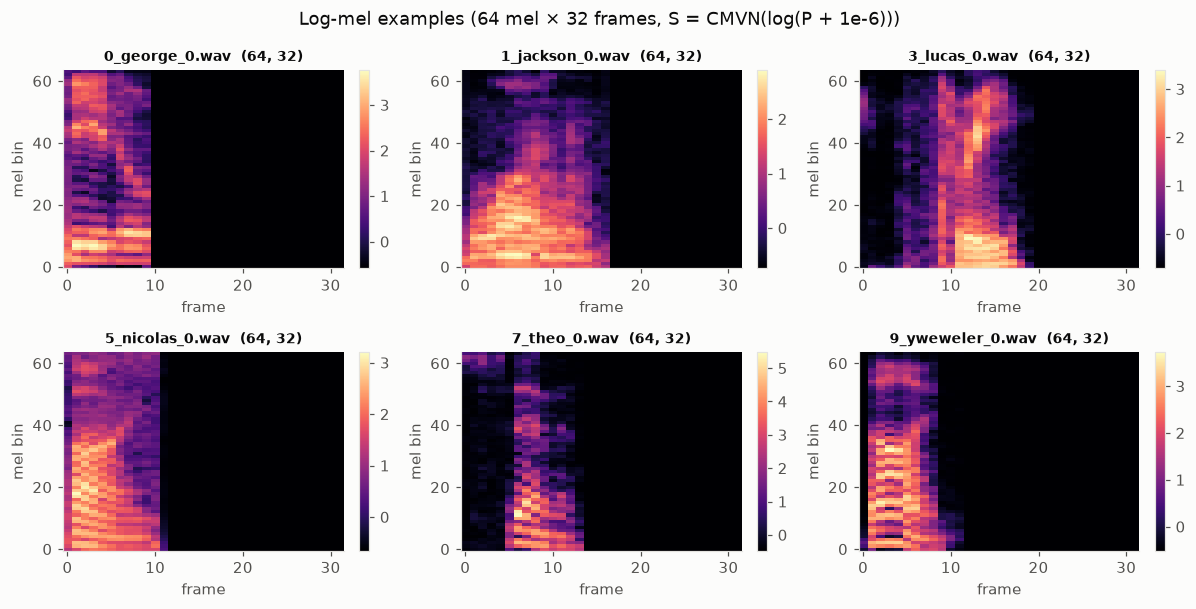

In [5]:
picks = [(0, 'george'), (1, 'jackson'), (3, 'lucas'), (5, 'nicolas'), (7, 'theo'), (9, 'yweweler')]
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6))
for ax, (dig, spk) in zip(axes.ravel(), picks):
    r = df[(df.label == dig) & (df.speaker == spk)].sort_values('recording_index').iloc[0]
    S = logmel(fix_length(load_wav(ROOT / r.path)[0]))
    im = ax.imshow(S, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(f'{r.filename}  {S.shape}', fontsize=9); ax.grid(False)
    ax.set_xlabel('frame'); ax.set_ylabel('mel bin'); fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Log-mel examples (64 mel × 32 frames, S = CMVN(log(P + 1e-6)))')
fig.tight_layout(); fig.savefig(FIG / 'logmel_examples.png'); plt.show()

## Kiểm tra normalization theo Train (Task 1.8)

In [6]:
from dataset import load_fold
rows = []
for fold in range(1, 7):
    sp, mu, sigma = load_fold(fold)
    assert mu.shape == (64,) and sigma.shape == (64,)
    for name, s in sp.items():
        rows.append(dict(fold=fold, split=name, speakers=','.join(sorted(s.meta.speaker.unique())),
                         n=len(s.y), mean=s.x.mean(), std=s.x.std()))
norm_tab = pd.DataFrame(rows); norm_tab

,fold,split,speakers,n,mean,std
0,1,train,"lucas,nicolas,theo,yweweler",2000,5.960465e-09,1.000000
1,1,val,jackson,500,-2.531526e-02,0.997430
2,1,test,george,500,1.946973e-02,1.101896
3,2,train,"george,nicolas,theo,yweweler",2000,2.574921e-08,1.000000
4,2,val,lucas,500,2.925096e-03,1.037292
5,2,test,jackson,500,-2.466825e-02,0.989296
6,3,train,"george,jackson,theo,yweweler",2000,-1.811981e-08,1.000000
7,3,val,nicolas,500,1.764359e-02,1.033938
8,3,test,lucas,500,8.543623e-03,1.039033
9,4,train,"george,jackson,lucas,yweweler",2000,0.000000e+00,1.000000


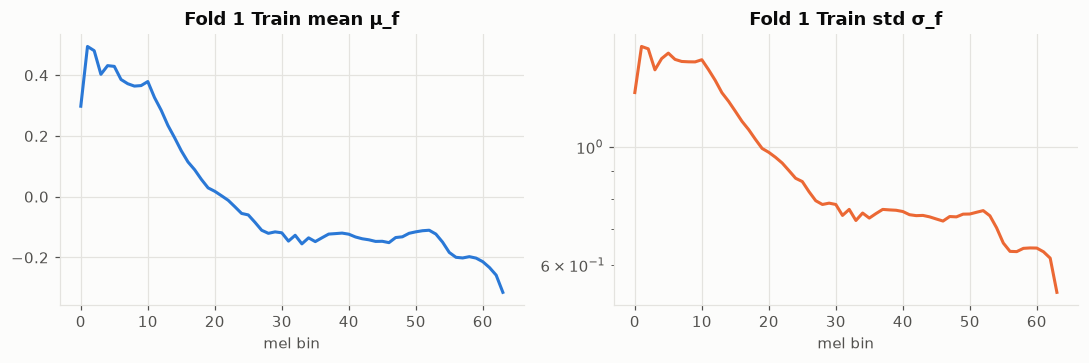

In [7]:
sp, mu, sigma = load_fold(1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(mu, color=SERIES[0]); axes[0].set(title='Fold 1 Train mean μ_f', xlabel='mel bin')
axes[1].plot(sigma, color=SERIES[1]); axes[1].set(title='Fold 1 Train std σ_f', xlabel='mel bin', yscale='log')
fig.tight_layout(); fig.savefig(FIG / 'normalization_fold1_stats.png'); plt.show()